#**AGEN/BSEN 892 AI & Visual Intelligence in Smart Agriculture**
#**Week 4. Machine Learning I - Linear Regression**
<br/><br/>


#**Exercise 1: US Greenhouse Gas Emission**
Dataset: https://www.kaggle.com/datasets/unitednations/international-greenhouse-gas-emissions

The dataset provides greenhouse gas emissions reported by various countries across multiple years. In this task, the focus is on analyzing carbon dioxide (CO₂) emissions excluding land use, land-use change, and forestry (LULUCF), measured in kilotonnes of CO₂ equivalent, specifically for the United States.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/AGST 892/Week4/greenhouse_gas_inventory_data_data.csv")
target_category = 'carbon_dioxide_co2_emissions_without_land_use_land_use_change_and_forestry_lulucf_in_kilotonne_co2_equivalent'
us_data = df[df['country_or_area'] == 'United States of America'].copy()
us_CO2 = us_data[us_data['category'] == target_category].copy()

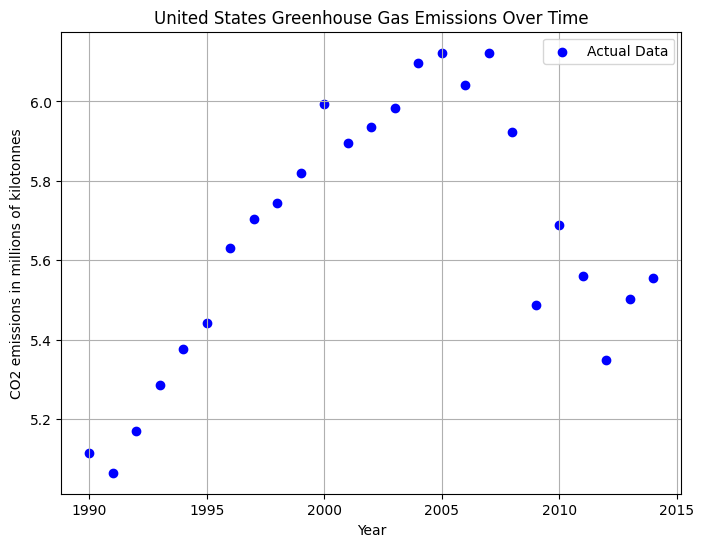

In [4]:
# Data preparation
# Explore the relationship Y = XW
X = us_CO2['year'].values.reshape(-1,1)
Y = us_CO2['value'].values.reshape(-1,1)

# print(X)
# print(Y)

# For computation efficiency, convert emisisons to millions of kilotonnes
Y = Y/1e6

# Plotting
plt.figure(figsize=(8,6))
plt.scatter(X, Y, color='blue', label='Actual Data')
plt.xlabel('Year')
plt.ylabel('CO2 emissions in millions of kilotonnes')
plt.title('United States Greenhouse Gas Emissions Over Time')
plt.legend()
plt.grid(True)
plt.show()

<br/><br/><br/>

#Exercise 1.1 Optimal solution
**Calculate the Optimal Solution** of the linear regression coefficients that can minimize the loss function and obtain the best fit line or the best model.



parameters from optimal solution
slope [0.0180197]
Intercept: [-30.41107484]


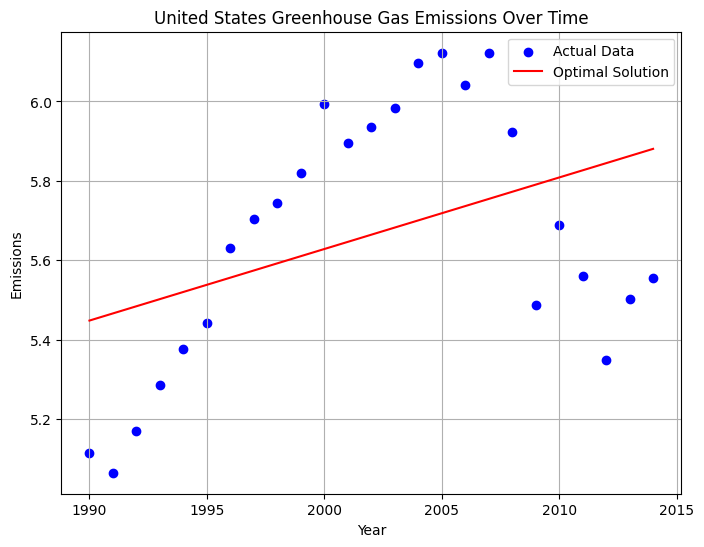

In [5]:
# optimal solution
# ----- Step 1: Add bias term to feature matrix
h = X.shape[0]
X_bias = np.hstack([X,np.ones((X.shape[0],1))])
# print(X_bias)

# Use the optimal solution formula to calculate the weights
w_opt = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ Y

print("\nparameters from optimal solution")
print("slope",w_opt[0])
print("Intercept:", w_opt[1])

# Plotting
plt.figure(figsize=(8,6))
plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X, X_bias@w_opt, color='red', label='Optimal Solution')
plt.xlabel('Year')
plt.ylabel('Emissions')
plt.title('United States Greenhouse Gas Emissions Over Time')
plt.legend()
plt.grid(True)
plt.show()

<br/>

#Exercise 1.2: scikit-learn LinearRegression package
Use scikit-learn package to fix the linear regression problem.

MSE: 0.08494735799698093
r2: 0.16581090626519002

parameters from scikit-learn
slope: [[0.0180197]]
Intercept: [-30.41107484]


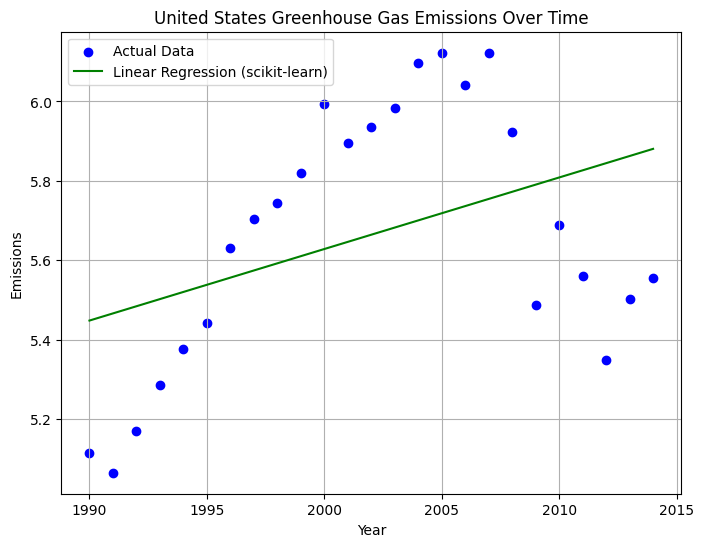

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

# Exercise 1.2
# Model the relationship between year (X) and emmisions (Y).
# fit the linear regression model to the data,finding the best-fitting line
# predict emissions using the trained model

model_sklearn = LinearRegression()
model_sklearn.fit(X, Y)
y_pred_sklearn = model_sklearn.predict(X)


# print out the mean_square error and r2 score between the predicted value and actual value
mse = mean_squared_error(Y, y_pred_sklearn)
r2__pred_sklearn =  r2_score(Y, y_pred_sklearn)
print("MSE:", mse)
print("r2:", r2__pred_sklearn)

# Compare the parameters to optimal solution
print("\nparameters from scikit-learn")
print("slope:", model_sklearn.coef_)
print("Intercept:", model_sklearn.intercept_)

# Plotting
plt.figure(figsize=(8,6))
plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X, y_pred_sklearn, color='green', label='Linear Regression (scikit-learn)')
plt.xlabel('Year')
plt.ylabel('Emissions')
plt.title('United States Greenhouse Gas Emissions Over Time')
plt.legend()
plt.grid(True)
plt.show()


# Exercise 1.3 Gradient Descent
Play with different initial parameters (learning_rate, n_iterations) and tell how the two parameters affect the solution and loss curve.

MSE: 0.08494735799698101


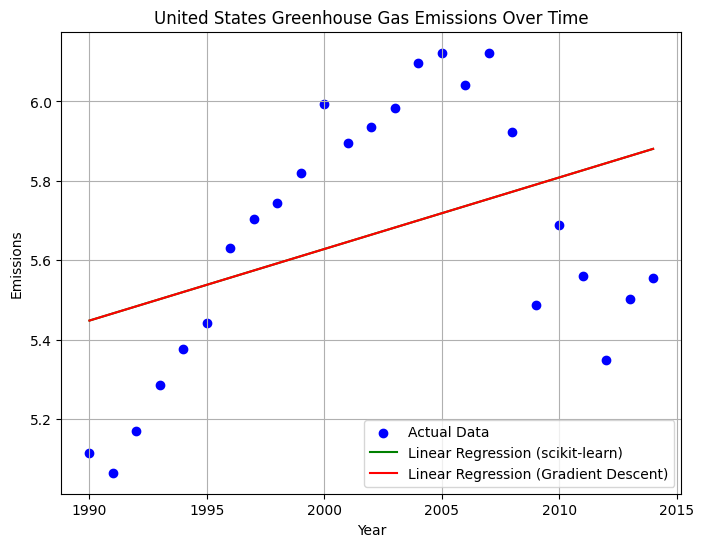

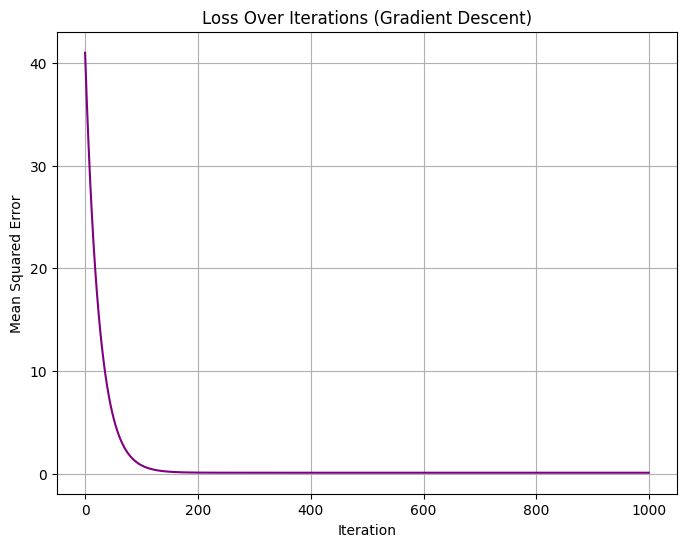

In [7]:
# Normalization in machine learning is the process of rescaling features so they share
# a similar range of distribution. Instead of letting raw features have very different magnitudes.
# It will also avoid extremely large gradient and help model to converge
X_norm = (X - np.mean(X))/np.std(X)

# Create a column of ones for the bias term (intercept)
h = X.shape[0]
ones = np.ones((h,1))
X_bias = np.hstack([X_norm,ones]) # Add bias term to feature vector

# Exercise 1.3
# Play with different initial parameters (learning_rate, n_iterations)
# Please tell how the two parameters affect the solution and loss curve.
learning_rate = 0.01
n_iterations = 1000
w = np.random.randn(2,1)
losses = []

# gradient descent algorithm
for iteration in range(n_iterations):
  error = X_bias@w - Y
  loss = np.mean(error**2)
  losses.append(loss)
  gradients = (2/h) * X_bias.T@error
  w -= learning_rate * gradients

  # Optional: monitor loss
  # if iteration % 10 == 0:
  #   print(f"Iteration {iteration}, Loss: {loss}")

# predictions using final weights
y_pred_gd = X_bias@w
print("MSE:",mean_squared_error(Y, y_pred_gd))

# Plott predictions
plt.figure(figsize=(8,6))
plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X, y_pred_sklearn, color='green', label='Linear Regression (scikit-learn)')
plt.plot(X, y_pred_gd, color='red', label='Linear Regression (Gradient Descent)')
plt.xlabel('Year')
plt.ylabel('Emissions')
plt.title('United States Greenhouse Gas Emissions Over Time')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss curve
plt.figure(figsize=(8,6))
plt.plot(range(n_iterations), losses, color='purple')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.title('Loss Over Iterations (Gradient Descent)')
plt.grid(True)
plt.show()

# A good animation for gradient descent: https://www.youtube.com/watch?v=T4cc7A0vchI

#Exercise 1.4 Ridge Regression and Lasso Regression
Play with parameter alpha in scikit-learn Ridge and Lasso pacakge and tell how the parameter affect the solution.

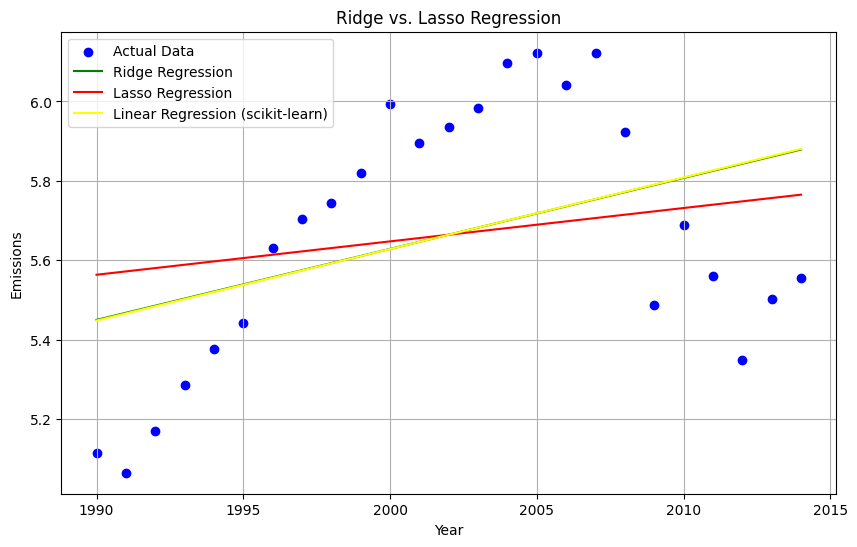

Ridge Regression:
Slope: [0.01788215]
Intercept: [-30.13568981]

Lasso Regression:
Slope: [0.00840432]
Intercept: [-11.16107484]


In [8]:
# ridge regression and lasso regression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

# Exercise 1.4
# Play with the alpha and max_iter in both Ridge and Lasso.
# Tell how alpha affect the model's result.
# --- Ridge Regression ---
ridge_model = Ridge(alpha=10.0)  # alpha is the regularization strength
ridge_model.fit(X, Y)
y_pred_ridge = ridge_model.predict(X)

# --- Lasso Regression ---
lasso_model = Lasso(alpha=0.5, max_iter=1000)  # Increase max_iter if needed
lasso_model.fit(X, Y)
y_pred_lasso = lasso_model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X, y_pred_ridge, color='green', label='Ridge Regression')
plt.plot(X, y_pred_lasso, color='red', label='Lasso Regression')
plt.plot(X, y_pred_sklearn, color='yellow', label='Linear Regression (scikit-learn)')
plt.xlabel('Year')
plt.ylabel('Emissions')
plt.title(f'Ridge vs. Lasso Regression')
plt.legend()
plt.grid(True)
plt.show()

print("Ridge Regression:")
print("Slope:", ridge_model.coef_)
print("Intercept:", ridge_model.intercept_)

print("\nLasso Regression:")
print("Slope:", lasso_model.coef_)
print("Intercept:", lasso_model.intercept_)

#Small alpha - model fits closely (risk of overfitting).
#Large alpha - stronger penalty, simpler model (risk of underfitting).
#Ridge = shrinkage, Lasso = shrinkage + feature elimination.

#Exericse 1.5 Polynomial Regrssion
For example: $y=w_1x^2+w_2x+w_3$

[[2.01400000e+03 4.05619600e+06 8.16917874e+09 1.64527260e+13]
 [2.01300000e+03 4.05216900e+06 8.15701620e+09 1.64200736e+13]
 [2.01200000e+03 4.04814400e+06 8.14486573e+09 1.63874698e+13]
 [2.01100000e+03 4.04412100e+06 8.13272733e+09 1.63549147e+13]
 [2.01000000e+03 4.04010000e+06 8.12060100e+09 1.63224080e+13]
 [2.00900000e+03 4.03608100e+06 8.10848673e+09 1.62899498e+13]
 [2.00800000e+03 4.03206400e+06 8.09638451e+09 1.62575401e+13]
 [2.00700000e+03 4.02804900e+06 8.08429434e+09 1.62251787e+13]
 [2.00600000e+03 4.02403600e+06 8.07221622e+09 1.61928657e+13]
 [2.00500000e+03 4.02002500e+06 8.06015012e+09 1.61606010e+13]
 [2.00400000e+03 4.01601600e+06 8.04809606e+09 1.61283845e+13]
 [2.00300000e+03 4.01200900e+06 8.03605403e+09 1.60962162e+13]
 [2.00200000e+03 4.00800400e+06 8.02402401e+09 1.60640961e+13]
 [2.00100000e+03 4.00400100e+06 8.01200600e+09 1.60320240e+13]
 [2.00000000e+03 4.00000000e+06 8.00000000e+09 1.60000000e+13]
 [1.99900000e+03 3.99600100e+06 7.98800600e+09 1.596802

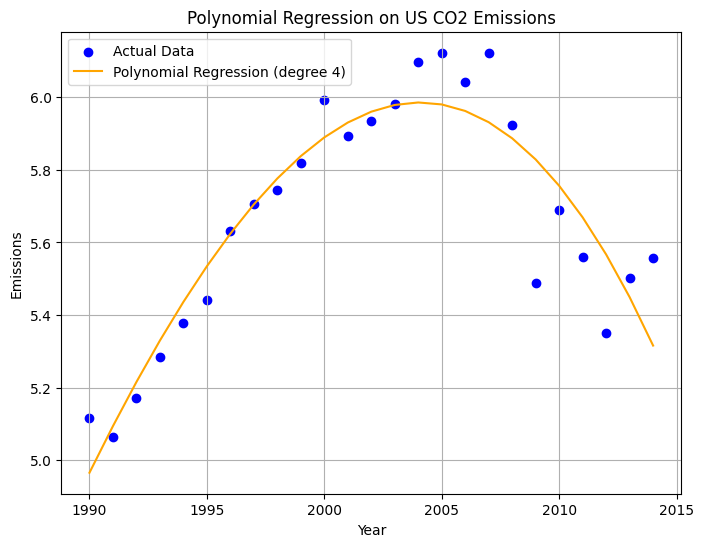

In [9]:
# polynomial regression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

# Create polynomial features (e.g., degree 2 or 3)
degree = 4  # You can try 2, 3, 4...
poly_features = PolynomialFeatures(degree=degree,include_bias=False)
X_poly_expanded = poly_features.fit_transform(X)
print(X_poly_expanded)

# Fit linear regression on the expanded features
poly_model = LinearRegression()
poly_model.fit(X_poly_expanded, Y)

# Predict emissions using the polynomial model
y_poly_pred = poly_model.predict(X_poly_expanded)

mse = mean_squared_error(Y, y_poly_pred)
print("MSE:", mse)
print("slope:", poly_model.coef_)
print("Intercept:", poly_model.intercept_)

# Step 5: Plot results
plt.figure(figsize=(8,6))
plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X, y_poly_pred, color='orange', label=f'Polynomial Regression (degree {degree})')
plt.xlabel('Year')
plt.ylabel('Emissions')
plt.title('Polynomial Regression on US CO2 Emissions')
plt.legend()
plt.grid(True)
plt.show()

#**Exercise 2: US Wheat Production**
Dataset: https://www.kaggle.com/datasets/sathyanarayanrao89/usda-wheat-production-and-acreage-data-1866-2022

The dataset provided consists of historical wheat production data, extracted from the USDA Economic Research Service's Wheat Data repository: USDA Wheat Data. This dataset covers several important agricultural metrics for wheat, including planted acreage, harvested acreage, production, yield, and farm price over multiple marketing years.

The objective of this analysis is to investigate the relationship between farm price and the two primary factors: yield and harvested acreage.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting

# --- Step 1: Load and Prepare Data ---
file_path = '/content/drive/MyDrive/AGST 892/Week4/wheat_production_data_cleaned (1).csv'
df = pd.read_csv(file_path)

# Drop rows with missing values in relevant columns
df_clean = df[['Harvested Acreage (Million Acres)', 'Yield (Bushels per Acre)', 'Farm Price (Dollars per Bushel)']].dropna()

# Extract features
X2 = df_clean[['Harvested Acreage (Million Acres)', 'Yield (Bushels per Acre)']].values
Y2 = df_clean['Farm Price (Dollars per Bushel)'].values


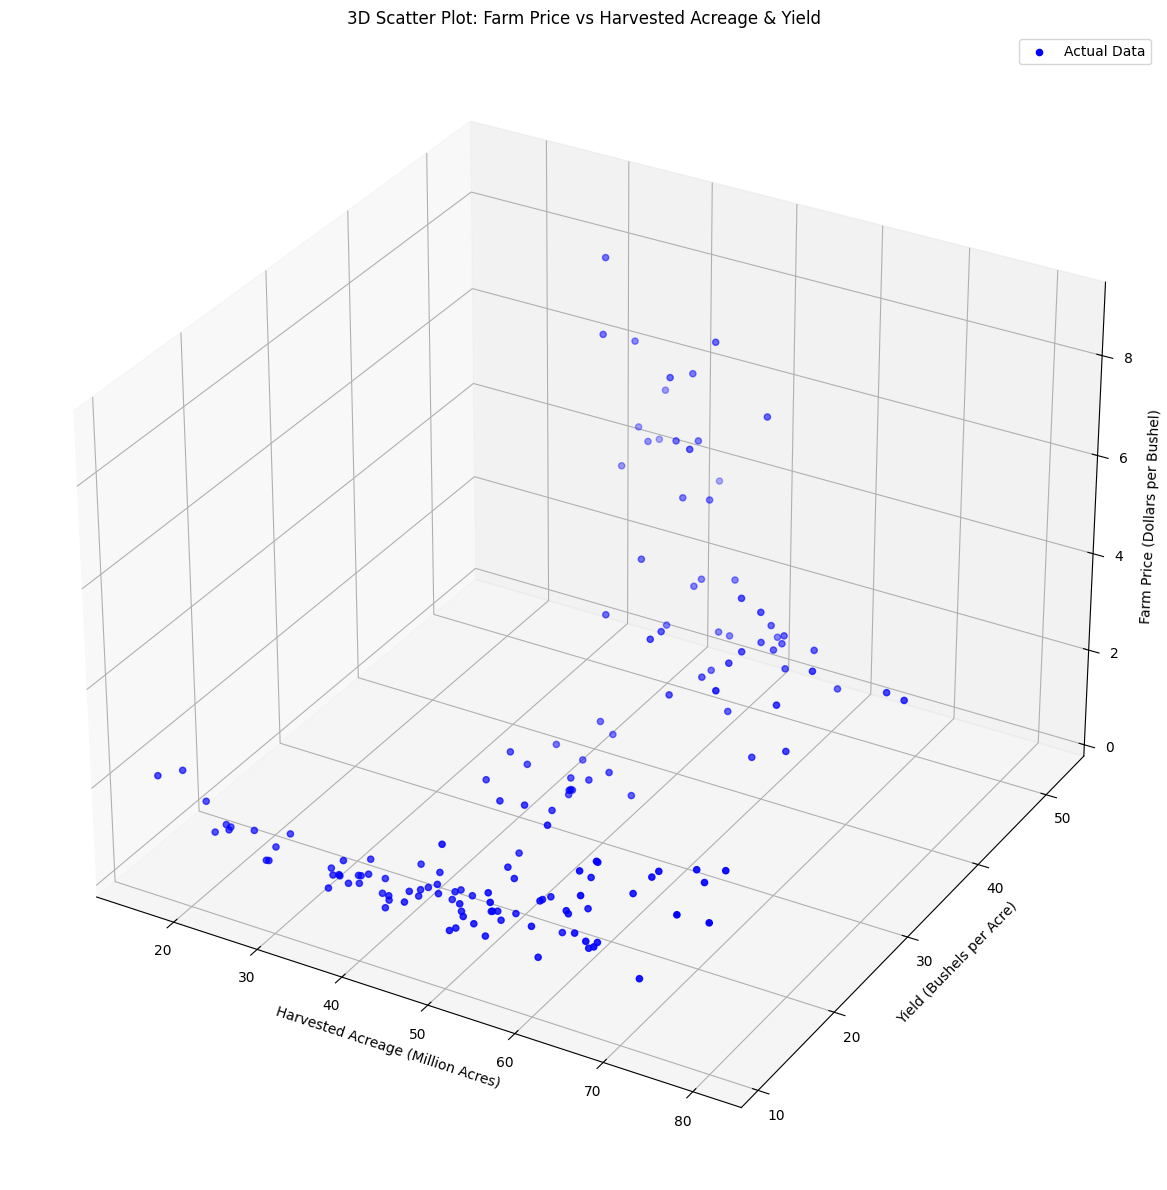

In [11]:
# Create 3D Scatter Plot ---
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot actual data points
ax.scatter(X2[:, 0], X2[:, 1], Y2, c='blue', label='Actual Data')

# Set axis labels
ax.set_xlabel('Harvested Acreage (Million Acres)')
ax.set_ylabel('Yield (Bushels per Acre)')
ax.set_zlabel('Farm Price (Dollars per Bushel)')
ax.set_title('3D Scatter Plot: Farm Price vs Harvested Acreage & Yield')
# ax.view_init(elev=30, azim=120)
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Split the data into 80% training, 20% testing
X_train, X_test, Y_train, Y_test = train_test_split(X2, Y2, test_size=0.2)

# Exercise 2.2: Scikit-learn Linear Regression
model_sklearn = LinearRegression()
model_sklearn.fit(X_train, Y_train)
y_pred_sklearn_train = model_sklearn.predict(X_train)
y_pred_sklearn_test = model_sklearn.predict(X_test)

# Exercise 2.3 Evaluate scikit-learn model for both training and test data
mse_sklearn_train = mean_squared_error(Y_train, y_pred_sklearn_train)
mse_sklearn_test = mean_squared_error(Y_test, y_pred_sklearn_test)

# print out the error and weights
print("Train MSE:", mse_sklearn_train)
print("Test MSE:", mse_sklearn_test)

print("slope:", model_sklearn.coef_)
print("Intercept:", model_sklearn.intercept_)

Train MSE: 0.8528567668377918
Test MSE: 0.7851955092218119
slope: [-0.00506016  0.12321273]
Intercept: -0.49324099301846847


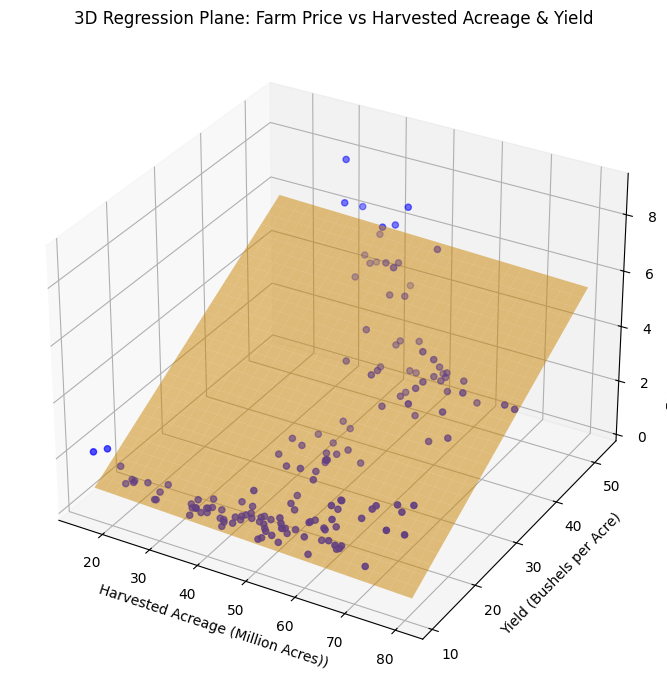

In [13]:
# Create meshgrid for surface plot
x_surf = np.linspace(X2[:, 0].min(), X2[:, 0].max(), 30)
y_surf = np.linspace(X2[:, 1].min(), X2[:, 1].max(), 30)
x_surf, y_surf = np.meshgrid(x_surf, y_surf)
xy_surf = np.c_[x_surf.ravel(), y_surf.ravel()]

# Predict prices on grid
z_surf = model_sklearn.predict(xy_surf).reshape(x_surf.shape)

# Plot 3D scatter + regression surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X2[:, 0], X2[:, 1], Y2, c='blue', label='Actual Data')
ax.plot_surface(x_surf, y_surf, z_surf, alpha=0.5, color='orange', label='Regression Plane')

# Labels
ax.set_xlabel('Harvested Acreage (Million Acres))')
ax.set_ylabel('Yield (Bushels per Acre)')
ax.set_zlabel('Farm Price (Dollars per Bushel)')
ax.set_title('3D Regression Plane: Farm Price vs Harvested Acreage & Yield')
# ax.view_init(elev=30, azim=120)
plt.tight_layout()
plt.show()

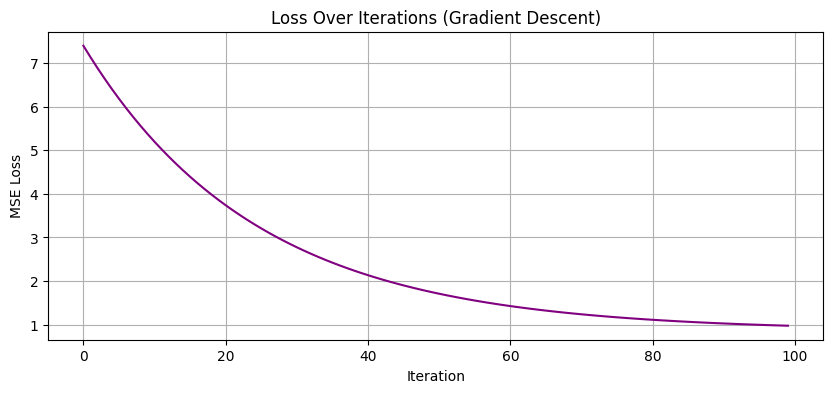

Train MSE: 0.9692010542384858
Test MSE: 0.7851955092218119
Train r2: 0.6942245246987817
Test r2: 0.6808460556943705


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Standard Normalize Training and Testing Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Gradient Descent Linear Regression
X_train_bias = np.hstack([X_train_scaled, np.ones((X_train_scaled.shape[0], 1))])  # Add bias term
X_test_bias = np.hstack([X_test_scaled, np.ones((X_test_scaled.shape[0], 1))])
w = np.random.randn(X_train_bias.shape[1], 1)
learning_rate = 0.01
n_iterations = 100
losses = []

for i in range(n_iterations):
    error = X_train_bias @ w - Y_train.reshape(-1, 1)
    loss = np.mean(error ** 2)
    losses.append(loss)
    gradients = 2/X_train_bias.shape[0] * X_train_bias.T @ error
    w -= learning_rate * gradients

# Predict using gradient descent
y_train_pred_gd = X_train_bias @ w
y_test_pred_gd = X_test_bias @ w

# Plot Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(losses, color='purple')
plt.title('Loss Over Iterations (Gradient Descent)')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()

# Calculate metrics, mean squared error and r2 score
mse_gd_train = mean_squared_error(Y_train, y_train_pred_gd)
mse_gd_test = mean_squared_error(Y_test, y_pred_sklearn_test)
r2_gd_train = r2_score(Y_train, y_train_pred_gd)
r2_gd_test = r2_score(Y_test, y_test_pred_gd)

print("Train MSE:", mse_gd_train)
print("Test MSE:", mse_gd_test)
print("Train r2:", r2_gd_train)
print("Test r2:", r2_gd_test)

In [15]:
print(w)

[[0.11935891]
 [1.47627669]
 [1.88395484]]


#**Homework**
Dataset: https://www.kaggle.com/code/waqi786/climate-change-agriculture-analysis/input

Task: Find a type of crop (filter by crop_type) and explore the relationship between yield and its factors: temperature, precipitation,extreme weather events, Irrigation access, pesticide use, fertilizer use, soil health index and Adaptation_Strategies (So **year, country, region CO2 emmision and economic impact will not be used**).

Please:
* Split the datset into train and test set. Check the datapoints first and try at least **two** different models to work.
* Call out what models you used and print out the weights and the metrics (at least including mean squared error and r2_score) for both training set and test set.
* Compare the models and identify what is the best one and tell why this model probably works better than the others.
* Leave comments in your codes for readability.

**Note**: When working with categorical data (e.g., categories A,B,C, and D), each category can be reprsented as a new column. For example, if a datapopint belongs to class A, then the column A is set to 1 while columns B,C and D set to 0. This process is known as "one hot encoding". In python, you might find sklearn.preprocessing.OneHotEncoder helpful.

**Rubic**:

model 1:
* train - test split [1pt]
* training [2pts]
* trained weights [2pts]
* apply on test set [1pt]
* metrics on training set [1pt]
* metrics on test set [1pt]

model 2:
* train - test split [1pt]
* training [2pts]
* trained weights [2pts]
* apply on test set [1pt]
* metrics on training set [1pt]
* metrics on test set [1pt]

Compare two models and analysis [4pts]

Dataset shape: (10000, 15)
First few rows:
    Year Country         Region  Crop_Type  Average_Temperature_C  \
0  2001   India    West Bengal       Corn                   1.55   
1  2024   China          North       Corn                   3.23   
2  2001  France  Ile-de-France      Wheat                  21.11   
3  2001  Canada       Prairies     Coffee                  27.85   
4  1998   India     Tamil Nadu  Sugarcane                   2.19   

   Total_Precipitation_mm  CO2_Emissions_MT  Crop_Yield_MT_per_HA  \
0                  447.06             15.22                 1.737   
1                 2913.57             29.82                 1.737   
2                 1301.74             25.75                 1.719   
3                 1154.36             13.91                 3.890   
4                 1627.48             11.81                 1.080   

   Extreme_Weather_Events  Irrigation_Access_%  Pesticide_Use_KG_per_HA  \
0                       8                14.54           

Text(0.5, 1.0, 'Crop Yield Over Time')

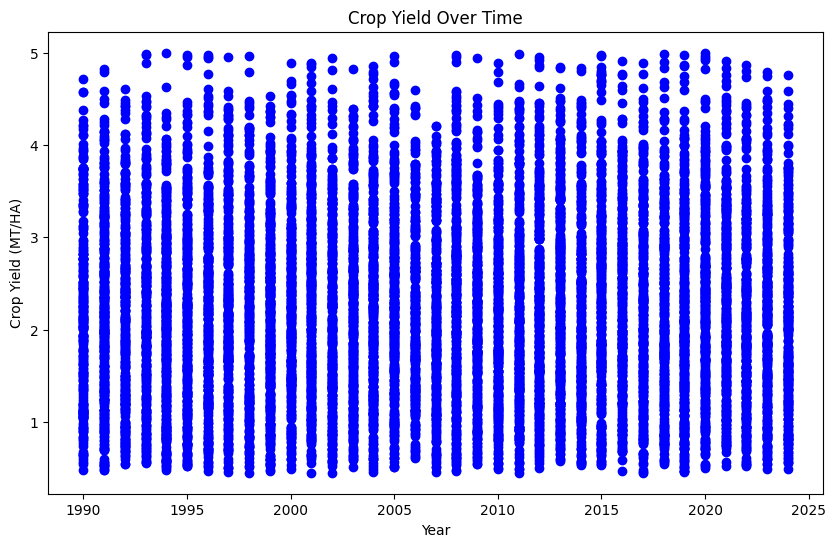

In [16]:
#Task: Find a type of crop (filter by crop_type) and explore the relationship between yield and
#its factors: temperature, precipitation,extreme weather events, Irrigation access, pesticide use, fertilizer use, soil health index and
#Adaptation_Strategies (So year, country, region CO2 emmision and economic impact will not be used).



import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# 1 --- Load data
path = '/content/drive/MyDrive/AGST 892/Week4/climate_change_impact_on_agriculture_2024.csv'
df = pd.read_csv(path)
print("Dataset shape:", df.shape)
print("First few rows:\n", df.head())

#plot data
plt.figure(figsize=(10, 6))
plt.scatter(df['Year'], df['Crop_Yield_MT_per_HA'], color='blue', label='Crop Yield')
plt.xlabel('Year')
plt.ylabel('Crop Yield (MT/HA)')
plt.title('Crop Yield Over Time')



Selected crop: Wheat
Rows for this crop: 1047


Text(0, 0.5, 'Crop Yield (MT/HA)')

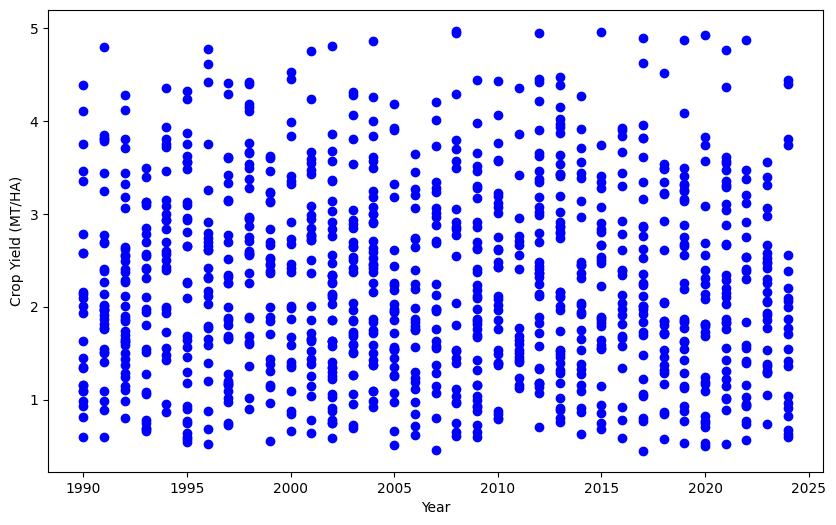

In [17]:
# 2 --- Pick a crop

crop_col = "Crop_Type"
top_crop = df[crop_col].value_counts().idxmax() #automatically finds the most frequent crop in the dataset
df_crop = df[df[crop_col] == top_crop].copy() #creates a filtered dataset that contains only rows for that crop

print("\nSelected crop:", top_crop)
print("Rows for this crop:", len(df_crop))

#plot data of wheat
plt.figure(figsize=(10, 6))
plt.scatter(df_crop['Year'], df_crop['Crop_Yield_MT_per_HA'], color='blue', label='Crop Yield')
plt.xlabel('Year')
plt.ylabel('Crop Yield (MT/HA)')


In [18]:
# #all type of crops
# print("\nAvailable crops and their counts:")
# print(df["Crop_Type"].value_counts())

# # Choose crop manually
# selected_crop = "Rice"   # change this to any crop name you want
# df_crop = df[df["Crop_Type"] == selected_crop].copy()

# print("\nSelected crop:", selected_crop)
# print("Rows for this crop:", len(df_crop))

In [19]:
# 3 --- Feature Selection

# Drop unused columns
df_crop = df_crop.drop(columns=["Year", "Country", "Region", "CO2_Emissions_MT", "Economic_Impact_Million_USD"])
print("\nDataset shape after dropping columns:", df_crop.shape)
print("First few rows after dropping columns:\n", df_crop.head())


Dataset shape after dropping columns: (1047, 10)
First few rows after dropping columns:
    Crop_Type  Average_Temperature_C  Total_Precipitation_mm  \
2      Wheat                  21.11                 1301.74   
8      Wheat                  32.08                 1233.10   
29     Wheat                  31.67                 2364.58   
45     Wheat                  12.18                 1647.58   
68     Wheat                  11.60                 2439.05   

    Crop_Yield_MT_per_HA  Extreme_Weather_Events  Irrigation_Access_%  \
2                  1.719                       5                84.42   
8                  2.990                       1                45.87   
29                 3.330                       4                72.38   
45                 1.872                       8                36.61   
68                 4.790                       6                27.81   

    Pesticide_Use_KG_per_HA  Fertilizer_Use_KG_per_HA  Soil_Health_Index  \
2               

In [20]:
# 4 --- Define Features and Target

# Define features (X) and target (Y)
# The target variable is 'Crop_Yield_MT_per_HA'
Y = df_crop['Crop_Yield_MT_per_HA']

# Features are all other columns except the target
X = df_crop.drop(columns=['Crop_Yield_MT_per_HA'])

print("\nFeatures (X) shape:", X.shape)
print("Target (Y) shape:", Y.shape)
print("\nFeatures (X) head:\n", X.head())
print("\nTarget (Y) head:\n", Y.head())


Features (X) shape: (1047, 9)
Target (Y) shape: (1047,)

Features (X) head:
    Crop_Type  Average_Temperature_C  Total_Precipitation_mm  \
2      Wheat                  21.11                 1301.74   
8      Wheat                  32.08                 1233.10   
29     Wheat                  31.67                 2364.58   
45     Wheat                  12.18                 1647.58   
68     Wheat                  11.60                 2439.05   

    Extreme_Weather_Events  Irrigation_Access_%  Pesticide_Use_KG_per_HA  \
2                        5                84.42                    27.41   
8                        1                45.87                    10.09   
29                       4                72.38                    48.77   
45                       8                36.61                    43.15   
68                       6                27.81                    38.14   

    Fertilizer_Use_KG_per_HA  Soil_Health_Index    Adaptation_Strategies  
2          

In [33]:
# 5 --- Handle Categorical Features

# Identify categorical and numerical columns
categorical_features = ['Crop_Type', 'Adaptation_Strategies']
print("\nCategorical features:", categorical_features)

numerical_features = [col for col in X.columns if col not in categorical_features]
print("\nNumerical features:", numerical_features)

# Create a column transformer for preprocessing
# This will apply OneHotEncoder to categorical features and StandardScaler to numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep other columns (if any) - though we've dropped them
)
print("\nPreprocessor:", preprocessor)

# Apply the preprocessing
X_processed = preprocessor.fit_transform(X)

print("\nProcessed features shape:", X_processed.shape)

# Get back feature names
feature_names = preprocessor.get_feature_names_out()

# Convert to DataFrame for readability
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

print(X_processed_df.head())  # first 5 rows with column names
print("\nAll feature names:", feature_names)





Categorical features: ['Crop_Type', 'Adaptation_Strategies']

Numerical features: ['Average_Temperature_C', 'Total_Precipitation_mm', 'Extreme_Weather_Events', 'Irrigation_Access_%', 'Pesticide_Use_KG_per_HA', 'Fertilizer_Use_KG_per_HA', 'Soil_Health_Index']

Preprocessor: ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['Average_Temperature_C',
                                  'Total_Precipitation_mm',
                                  'Extreme_Weather_Events',
                                  'Irrigation_Access_%',
                                  'Pesticide_Use_KG_per_HA',
                                  'Fertilizer_Use_KG_per_HA',
                                  'Soil_Health_Index']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Crop_Type', 'Adaptation_Strategies'])])

Processed features shape: (1047, 13)
   num__Average

In [34]:
# 6 --- Split Data

# Split the processed data into training and testing sets
# We'll use 80% for training and 20% for testing,
X_train, X_test, Y_train, Y_test = train_test_split(X_processed, Y, test_size=0.2, random_state=42) # Using a random state for reproducibility

print("\nTraining features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", Y_train.shape)
print("Testing target shape:", Y_test.shape)


Training features shape: (837, 13)
Testing features shape: (210, 13)
Training target shape: (837,)
Testing target shape: (210,)



Y Train
 [2.20517331 2.13085335 2.33046037 1.96042394 2.58109412 2.40781278
 2.19775996 2.54927166 2.63993218 2.32304828 2.36680162 2.07118811
 1.93137418 2.36057467 2.58307444 1.86327532 2.41550322 2.07934731
 2.32759285 2.40688708 2.60324997 2.02122745 2.02071209 2.52768883
 2.27107041 2.54374499 2.04276938 2.34343326 1.63049508 2.52221016
 2.20286341 2.09728757 1.93657621 2.36301717 2.55123705 2.03153348
 2.08780878 2.57172492 2.47618502 2.11928664 2.35737031 2.07512367
 2.48415013 1.76715593 2.11495434 2.1207588  1.98479351 2.18681835
 2.61189385 2.13052723 2.63292661 2.47693558 1.99353821 2.39224917
 2.1660036  1.91686037 2.10481983 2.30228723 2.68999459 1.83876803
 2.65910376 2.44885823 2.58597706 2.15619017 2.46339065 1.91263082
 2.32785097 2.30371957 2.46323551 2.25300352 2.21073812 2.35143895
 2.5097659  2.03900883 2.46170487 2.54044025 2.07247726 2.64836271
 1.83430366 1.89861877 2.27956377 2.28917394 1.97483409 2.65685971
 2.50898385 2.60530556 2.44662292 2.33852921 2.49012

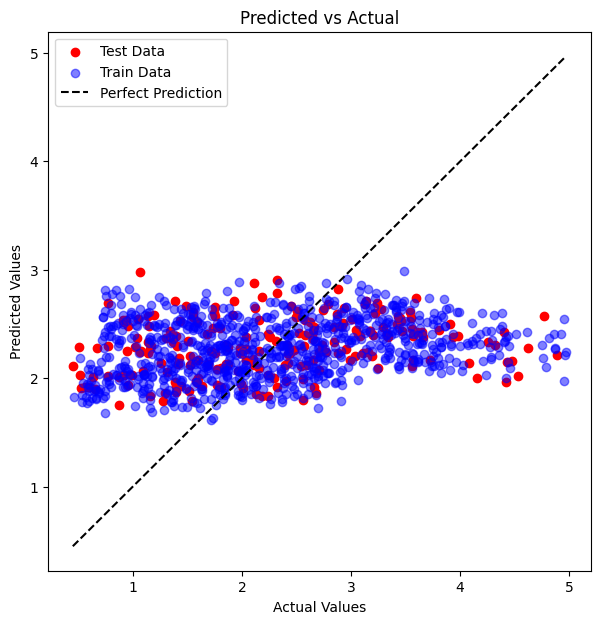

In [41]:
# 7 --- Build and Train Model 1: Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Linear Regression model
model_1 = LinearRegression()
model_1.fit(X_train, Y_train)

# 8 --- Evaluate Model 1

# Predict on the training set
Y_train_pred_m1 = model_1.predict(X_train)
print("\nY Train\n",Y_train_pred_m1)
# Predict on the test set
Y_test_pred_m1 = model_1.predict(X_test)
print("\nY Test\n",Y_test_pred_m1)
# Calculate metrics for the training set
mse_train_m1 = mean_squared_error(Y_train, Y_train_pred_m1)
r2_train_m1 = r2_score(Y_train, Y_train_pred_m1)

# Calculate metrics for the test set
mse_test_m1 = mean_squared_error(Y_test, Y_test_pred_m1)
r2_test_m1 = r2_score(Y_test, Y_test_pred_m1)

print("--- Model 1: Linear Regression ---")
print("\nTraining Set Metrics:")
print(f"Mean Squared Error (MSE): {mse_train_m1:.4f}")
print(f"R-squared (R2): {r2_train_m1:.4f}")

print("\nTest Set Metrics:")
print(f"Mean Squared Error (MSE): {mse_test_m1:.4f}")
print(f"R-squared (R2): {r2_test_m1:.4f}")

print("\nModel 1 Weights (Coefficients):", model_1.coef_)
print("Model 1 Intercept:", model_1.intercept_)

#plot

plt.figure(figsize=(7,7))
plt.scatter(Y_test, Y_test_pred_m1, color='red', label='Test Data')
plt.scatter(Y_train, Y_train_pred_m1, color='blue', alpha=0.5, label='Train Data')

# Perfect prediction line
lims = [min(Y_test.min(), Y_train.min()), max(Y_test.max(), Y_train.max())]
plt.plot(lims, lims, 'k--', label='Perfect Prediction')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.title("Predicted vs Actual")
plt.show()

--- Model 2: Ridge Regression ---

Training Set Metrics:
Mean Squared Error (MSE): 0.9990
R-squared (R2): 0.0669

Test Set Metrics:
Mean Squared Error (MSE): 0.9802
R-squared (R2): 0.0470

Model 2 Weights (Coefficients): [ 0.24449593  0.00649652  0.04262674  0.0256574  -0.01076859  0.07163567
 -0.03329044  0.         -0.05201969 -0.05860371  0.15417002 -0.01406987
 -0.02947675]
Model 2 Intercept: 2.274821805861511


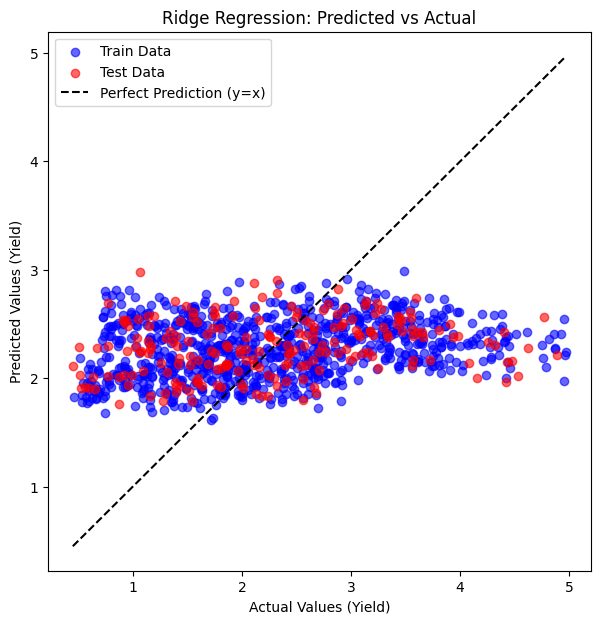

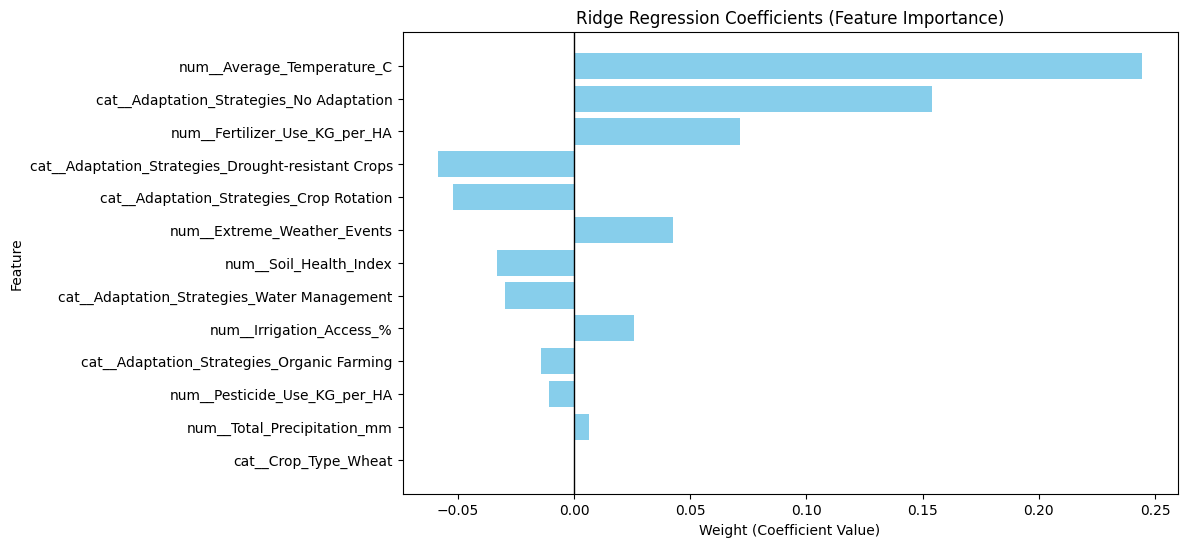

In [44]:
# 9 --- Build and Train Model 2: Ridge Regression

from sklearn.linear_model import Ridge

# Initialize and train the Ridge Regression model

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, Y_train)

# 10 --- Evaluate Model 2

# Predict on the training set
Y_train_pred_m2 = ridge_model.predict(X_train)

# Predict on the test set
Y_test_pred_m2 = ridge_model.predict(X_test)

# Calculate metrics for the training set
mse_train_m2 = mean_squared_error(Y_train, Y_train_pred_m2)
r2_train_m2 = r2_score(Y_train, Y_train_pred_m2)

# Calculate metrics for the test set
mse_test_m2 = mean_squared_error(Y_test, Y_test_pred_m2)
r2_test_m2 = r2_score(Y_test, Y_test_pred_m2)

print("--- Model 2: Ridge Regression ---")
print("\nTraining Set Metrics:")
print(f"Mean Squared Error (MSE): {mse_train_m2:.4f}")
print(f"R-squared (R2): {r2_train_m2:.4f}")

print("\nTest Set Metrics:")
print(f"Mean Squared Error (MSE): {mse_test_m2:.4f}")
print(f"R-squared (R2): {r2_test_m2:.4f}")

print("\nModel 2 Weights (Coefficients):", ridge_model.coef_)
print("Model 2 Intercept:", ridge_model.intercept_)


# --- 1. Predicted vs Actual Scatter Plot ---
plt.figure(figsize=(7,7))
plt.scatter(Y_train, Y_train_pred_m2, color='blue', alpha=0.6, label="Train Data")
plt.scatter(Y_test, Y_test_pred_m2, color='red', alpha=0.6, label="Test Data")

# Perfect prediction reference line
lims = [min(Y_train.min(), Y_test.min()), max(Y_train.max(), Y_test.max())]
plt.plot(lims, lims, 'k--', label="Perfect Prediction (y=x)")

plt.xlabel("Actual Values (Yield)")
plt.ylabel("Predicted Values (Yield)")
plt.title("Ridge Regression: Predicted vs Actual")
plt.legend()
plt.show()


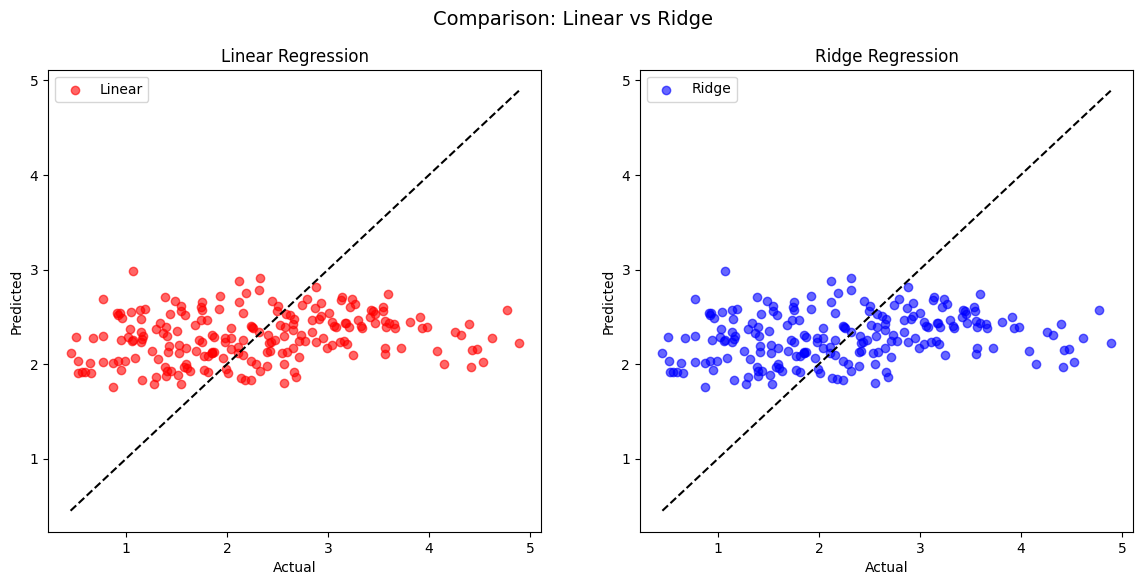

In [45]:
#compare two models


fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Left: Linear Regression
axes[0].scatter(Y_test, Y_test_pred_m1, color='red', alpha=0.6, label="Linear")
axes[0].plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--')
axes[0].set_title("Linear Regression")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].legend()

# Right: Ridge Regression
axes[1].scatter(Y_test, Y_test_pred_m2, color='blue', alpha=0.6, label="Ridge")
axes[1].plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--')
axes[1].set_title("Ridge Regression")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")
axes[1].legend()

plt.suptitle("Comparison: Linear vs Ridge", fontsize=14)
plt.show()


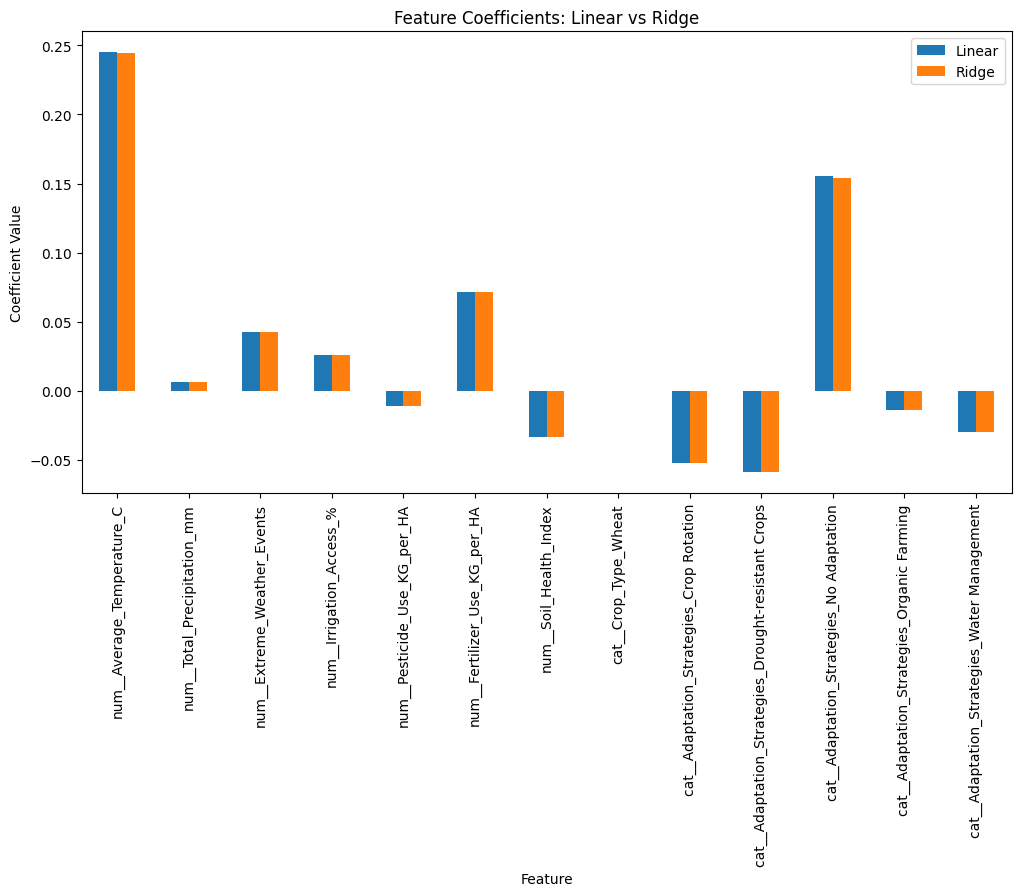

In [47]:
feature_names = preprocessor.get_feature_names_out()

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Linear": model_1.coef_,
    "Ridge": ridge_model.coef_
})

coef_df.plot(x="Feature", kind="bar", figsize=(12,6))
plt.title("Feature Coefficients: Linear vs Ridge")
plt.ylabel("Coefficient Value")
plt.show()


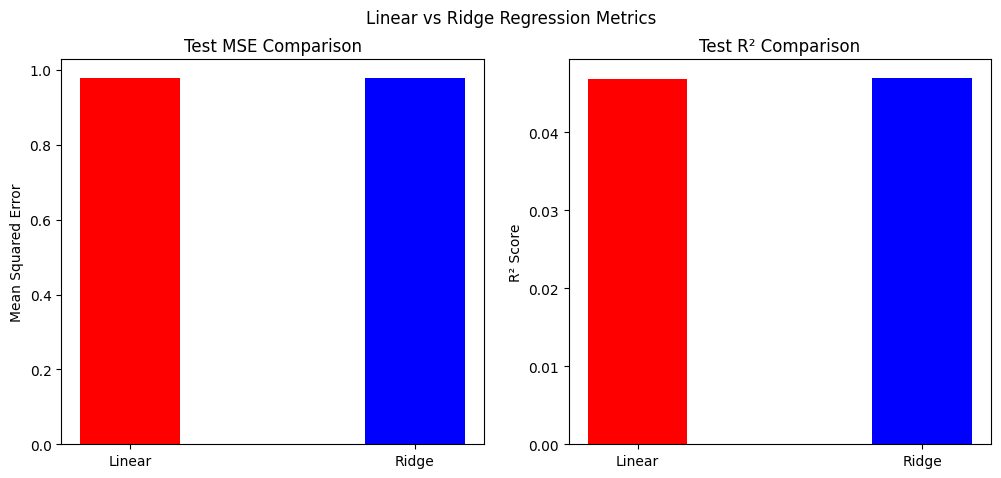

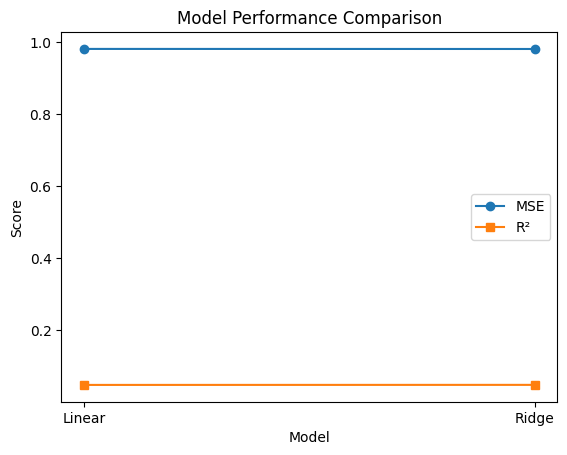

In [48]:
#compare two models

import matplotlib.pyplot as plt
import numpy as np

models = ["Linear", "Ridge"]
mse_values = [mse_test_m1, mse_test_m2]   # test MSE from both models
r2_values  = [r2_test_m1, r2_test_m2]     # test R² from both models

x = np.arange(len(models))  # positions for bars
width = 0.35

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# MSE comparison
ax[0].bar(x, mse_values, width, color=['red','blue'])
ax[0].set_xticks(x)
ax[0].set_xticklabels(models)
ax[0].set_title("Test MSE Comparison")
ax[0].set_ylabel("Mean Squared Error")

# R² comparison
ax[1].bar(x, r2_values, width, color=['red','blue'])
ax[1].set_xticks(x)
ax[1].set_xticklabels(models)
ax[1].set_title("Test R² Comparison")
ax[1].set_ylabel("R² Score")

plt.suptitle("Linear vs Ridge Regression Metrics")
plt.show()

plt.plot(models, mse_values, marker='o', label="MSE")
plt.plot(models, r2_values, marker='s', label="R²")
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.show()



### 1. Metrics Comparison


**Linear Regression**

* Train MSE = 0.9990, R² ≈ 0.0669
* Test MSE = 0.9803, R² ≈ 0.0469

**Ridge Regression (α=1.0)**

* Train MSE = 0.9990, R² ≈ 0.0669
* Test MSE = 0.9802, R² ≈ 0.0470

Interpretation:

* Both models perform **almost identically** (very low R² ≈ 0.05).
* That means **neither model explains much variance** in the crop yield (\~5%).
* Ridge does not improve performance much because dataset may be **underfitting** (features don’t strongly predict the target).

### 2. Predicted vs Actual Plots

* Both scatter plots show points **scattered away from the diagonal line (y = x)**.
* That means predictions don’t match actual yields closely.
* No model clearly outperforms the other visually.

### 3. Coefficient (Feature Importance) Comparison

* Both Linear and Ridge assign **similar coefficients**.
* Ridge slightly **shrinks weights** (bars are a bit closer to 0).
* This is the expected behavior: Ridge penalizes large weights, making the model more stable.


### Final Conclusion

* **Both models perform poorly** (low R²), meaning the chosen features don’t strongly explain crop yield.
* **Ridge doesn’t improve much** vs plain Linear Regression at α=1.0.
* But Ridge has the advantage of being **more stable** if you had highly correlated features or noisy data.
* For your case, the issue is not the model, but the **data signal** → features may not contain enough predictive power.


#Pre-class reading:
Please review the following resources before class:
* Logistic Regression: https://www.geeksforgeeks.org/machine-learning/understanding-logistic-regression/
* Support Vector Machine: https://www.geeksforgeeks.org/machine-learning/support-vector-machine-algorithm/